# Preprocessing Pipeline — Time-Series Hedge-Fund Forecasting (AML)

This notebook implements every preprocessing action identified in `01-EDA.ipynb`
and `02-Advanced-EDA.ipynb`. Each step includes **before / after visualisations**
and is wrapped into a **reusable pipeline module** (`pipeline/preprocess.py`)
for use in feature engineering and modelling notebooks.

---

## Preprocessing Roadmap (from EDA)

| Step | Action | EDA Source |
|------|--------|-----------|
| 1 | Drop noise features (`feature_b`–`feature_g`) | EDA §3.6 |
| 2 | Drop one from each redundant pair (`feature_bo`, `feature_af`, `feature_cd`) | EDA §5.3 |
| 3 | Add `_is_missing` flags for high-missing features (>5%) | EDA §2.2 |
| 4 | Group-aware median imputation (by `code` × `sub_category`) | EDA §2.2 |
| 5 | Encode categoricals (`code`, `sub_code`, `sub_category`) | EDA §3.5 |
| 6 | Clip target at 1st/99th percentile | EDA §3.1 |
| 7 | Compute horizon-normalised target | EDA §3.2 |
| 8 | Keep `weight` as-is (used only for weighted RMSE scoring, not training) | EDA §3.4 |
| 9 | Save processed parquets + reusable pipeline | — |

---

## 1. Setup & Raw Data Loading

In [3]:
import warnings, os, gc, sys
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = os.path.join('..', 'data')
PIPELINE_DIR = os.path.join('..', 'pipeline')
os.makedirs(PIPELINE_DIR, exist_ok=True)

train_raw = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
test_raw  = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f'Raw Train: {train_raw.shape}  |  Raw Test: {test_raw.shape}')

Raw Train: (5337414, 94)  |  Raw Test: (1447107, 92)


### 1.1 Define Column Groups

In [6]:
ALL_FEATURE_COLS = [c for c in train_raw.columns if c.startswith('feature_')]

# From EDA: noise features (zero correlation, identical distributions)
NOISE_FEATURES = ['feature_b', 'feature_c', 'feature_d',
                  'feature_e', 'feature_f', 'feature_g']

# From EDA: one from each highly-correlated pair (r > 0.95)
# Keeping: feature_bm (drop feature_bo), feature_u (drop feature_af), feature_bz (drop feature_cd)
REDUNDANT_FEATURES = ['feature_bo', 'feature_af', 'feature_cd']

FEATURES_TO_DROP = NOISE_FEATURES + REDUNDANT_FEATURES

# From EDA: features with >5% missing → create _is_missing flags
HIGH_MISSING_FEATURES = ['feature_at', 'feature_by', 'feature_ay',
                         'feature_ce', 'feature_cf']

CAT_COLS = ['code', 'sub_code', 'sub_category']
META_COLS = ['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index']
TARGET_COL = 'y_target'
WEIGHT_COL = 'weight'

print(f'Total features: {len(ALL_FEATURE_COLS)}')
print(f'Noise features to drop: {len(NOISE_FEATURES)}')
print(f'Redundant features to drop: {len(REDUNDANT_FEATURES)}')
print(f'Features after cleanup: {len(ALL_FEATURE_COLS) - len(FEATURES_TO_DROP)}')
print(f'High-missing features (>5%): {len(HIGH_MISSING_FEATURES)}')

Total features: 86
Noise features to drop: 6
Redundant features to drop: 3
Features after cleanup: 77
High-missing features (>5%): 5


---
## 2. Step 1 — Drop Noise & Redundant Features

**EDA evidence:**
- `feature_b`–`feature_g` have identical distributions (mean ≈ 8.56, std ≈ 4.87),
  near-zero pairwise correlation with each other, and |r| < 0.001 with target.
- Three pairs have r > 0.95: `bm↔bo`, `u↔af`, `bz↔cd`. Keeping the one with
  higher target correlation from each pair.

In [9]:
# Before: show correlation of dropped features with target
print('=== Features Being Dropped ===')
for f in FEATURES_TO_DROP:
    r = train_raw[f].corr(train_raw[TARGET_COL])
    print(f'  {f:15s}  →  corr with target = {r:+.6f}')

print(f'\nDropping {len(FEATURES_TO_DROP)} features...')

train = train_raw.drop(columns=FEATURES_TO_DROP, errors='ignore').copy()
test  = test_raw.drop(columns=FEATURES_TO_DROP, errors='ignore').copy()

feature_cols = [c for c in train.columns if c.startswith('feature_')]
print(f'Remaining features: {len(feature_cols)}')
print(f'Train: {train.shape}  |  Test: {test.shape}')

=== Features Being Dropped ===
  feature_b        →  corr with target = -0.000089
  feature_c        →  corr with target = +0.000570
  feature_d        →  corr with target = +0.000097
  feature_e        →  corr with target = -0.000574
  feature_f        →  corr with target = -0.000027
  feature_g        →  corr with target = -0.000212
  feature_bo       →  corr with target = -0.058157
  feature_af       →  corr with target = -0.073544
  feature_cd       →  corr with target = +0.085975

Dropping 9 features...
Remaining features: 77
Train: (5337414, 85)  |  Test: (1447107, 83)


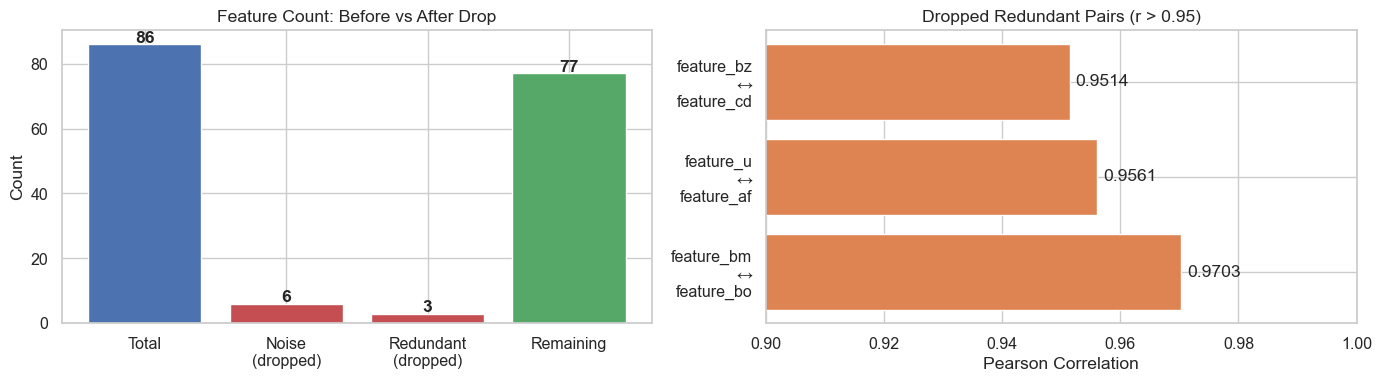

In [10]:
# Visual: Before vs After feature count
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

categories = ['Total', 'Noise\n(dropped)', 'Redundant\n(dropped)', 'Remaining']
values = [len(ALL_FEATURE_COLS), len(NOISE_FEATURES), len(REDUNDANT_FEATURES), len(feature_cols)]
colors = ['#4C72B0', '#C44E52', '#C44E52', '#55A868']
axes[0].bar(categories, values, color=colors)
axes[0].set_title('Feature Count: Before vs After Drop')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Show that dropped pairs were indeed redundant
pairs = [('feature_bm', 'feature_bo'), ('feature_u', 'feature_af'), ('feature_bz', 'feature_cd')]
pair_corrs = [train_raw[a].corr(train_raw[b]) for a, b in pairs]
labels = [f'{a}\n↔\n{b}' for a, b in pairs]
axes[1].barh(labels, pair_corrs, color='#DD8452')
axes[1].set_xlabel('Pearson Correlation')
axes[1].set_title('Dropped Redundant Pairs (r > 0.95)')
axes[1].set_xlim(0.9, 1.0)
for i, v in enumerate(pair_corrs):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

---
## 3. Step 2 — Missing Value Flags

**EDA evidence:** 48 columns have missing values. For features with >5% missing,
the *pattern of missingness* itself may carry information (e.g., certain entity
types lack this data). We create binary `_is_missing` flags before imputing.

In [12]:
# Before: missing rates for flagged features
print('=== Missing Rates for High-Missing Features ===')
for dataset, name in [(train, 'Train'), (test, 'Test')]:
    print(f'\n  {name}:')
    for f in HIGH_MISSING_FEATURES:
        if f in dataset.columns:
            pct = dataset[f].isnull().mean() * 100
            print(f'    {f:15s}: {pct:.2f}%')

=== Missing Rates for High-Missing Features ===

  Train:
    feature_at     : 12.47%
    feature_by     : 11.02%
    feature_ay     : 8.54%
    feature_ce     : 5.17%
    feature_cf     : 4.43%

  Test:
    feature_at     : 9.23%
    feature_by     : 9.20%
    feature_ay     : 5.80%
    feature_ce     : 3.53%
    feature_cf     : 3.53%


In [13]:
# Create _is_missing flags
for f in HIGH_MISSING_FEATURES:
    flag_name = f'{f}_is_missing'
    if f in train.columns:
        train[flag_name] = train[f].isnull().astype(np.int8)
    if f in test.columns:
        test[flag_name] = test[f].isnull().astype(np.int8)

missing_flags = [c for c in train.columns if c.endswith('_is_missing')]
print(f'Created {len(missing_flags)} missing-value flags: {missing_flags}')

Created 5 missing-value flags: ['feature_at_is_missing', 'feature_by_is_missing', 'feature_ay_is_missing', 'feature_ce_is_missing', 'feature_cf_is_missing']


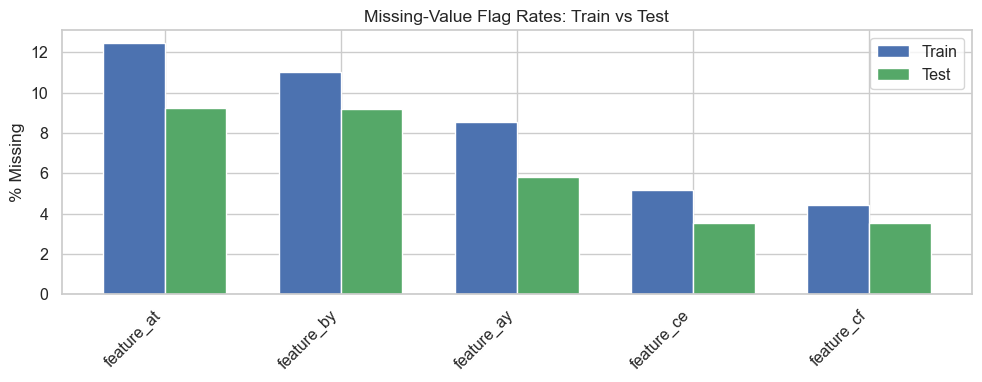

In [14]:
# Visual: missing flag distribution
fig, ax = plt.subplots(figsize=(10, 4))
flag_means_train = train[missing_flags].mean()
flag_means_test  = pd.Series({f: test[f].mean() if f in test.columns else 0 for f in missing_flags})

x = np.arange(len(missing_flags))
w = 0.35
ax.bar(x - w/2, flag_means_train * 100, w, label='Train', color='#4C72B0')
ax.bar(x + w/2, flag_means_test * 100, w, label='Test', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels([f.replace('_is_missing', '') for f in missing_flags], rotation=45, ha='right')
ax.set_ylabel('% Missing')
ax.set_title('Missing-Value Flag Rates: Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Step 3 — Group-Aware Median Imputation

**EDA evidence:** Missingness may be entity-specific. We impute with the median
computed per `code` × `sub_category` group. If a group has no observations for a
feature, we fall back to the global median.

In [16]:
# Before: total missing
missing_before_train = train[feature_cols].isnull().sum().sum()
missing_before_test  = test[[c for c in feature_cols if c in test.columns]].isnull().sum().sum()
print(f'Missing values BEFORE imputation:')
print(f'  Train: {missing_before_train:,}')
print(f'  Test:  {missing_before_test:,}')

Missing values BEFORE imputation:
  Train: 3,561,739
  Test:  2,929,192


In [17]:
# Compute group medians on TRAIN only (no leakage from test)
group_cols = ['code', 'sub_category']
cols_with_missing = [c for c in feature_cols if train[c].isnull().any()]

# Group medians
group_medians = train.groupby(group_cols)[cols_with_missing].median()

# Global medians as fallback
global_medians = train[cols_with_missing].median()

def impute_with_group_median(df, group_cols, group_med, global_med, cols):
    """Impute missing values using group medians with global fallback."""
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        mask = df[col].isnull()
        if mask.sum() == 0:
            continue
        # Map group medians
        fill_vals = df.loc[mask, group_cols].merge(
            group_med[[col]].reset_index(), on=group_cols, how='left'
        )[col]
        fill_vals.index = df.loc[mask].index
        # Fill with group median, then global fallback
        df.loc[mask, col] = fill_vals.fillna(global_med[col])
    return df

train = impute_with_group_median(train, group_cols, group_medians, global_medians, cols_with_missing)
test  = impute_with_group_median(test, group_cols, group_medians, global_medians, cols_with_missing)

# Any remaining NaN → global median (edge case: test groups not in train)
for col in cols_with_missing:
    if col in test.columns and test[col].isnull().any():
        test[col] = test[col].fillna(global_medians[col])

missing_after_train = train[feature_cols].isnull().sum().sum()
missing_after_test  = test[[c for c in feature_cols if c in test.columns]].isnull().sum().sum()
print(f'\nMissing values AFTER imputation:')
print(f'  Train: {missing_after_train:,}')
print(f'  Test:  {missing_after_test:,}')


Missing values AFTER imputation:
  Train: 0
  Test:  25,578


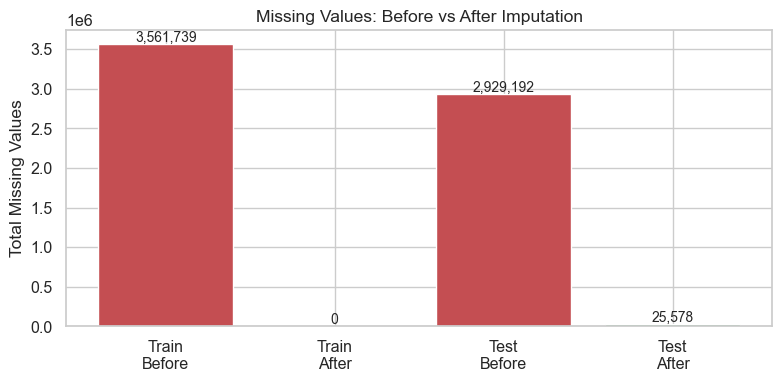

In [18]:
# Visual: Before vs After missing
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Train\nBefore', 'Train\nAfter', 'Test\nBefore', 'Test\nAfter']
vals   = [missing_before_train, missing_after_train, missing_before_test, missing_after_test]
colors = ['#C44E52', '#55A868', '#C44E52', '#55A868']
ax.bar(labels, vals, color=colors)
ax.set_ylabel('Total Missing Values')
ax.set_title('Missing Values: Before vs After Imputation')
for i, v in enumerate(vals):
    ax.text(i, v + max(vals)*0.01, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Step 4 — Encode Categorical Variables

**EDA evidence:** `code` (23 unique), `sub_code` (180 train / 47 test, only 12
overlap), `sub_category` (5 unique). For tree models, integer encoding is
sufficient. We use label encoding and store the mappings.

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    # Fit on combined unique values from train + test
    all_vals = pd.concat([train[col], test[col]]).unique()
    le.fit(all_vals)
    train[f'{col}_encoded'] = le.transform(train[col])
    test[f'{col}_encoded']  = le.transform(test[col])
    label_encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes → encoded as 0..{len(le.classes_)-1}')

encoded_cat_cols = [f'{c}_encoded' for c in CAT_COLS]

code: 23 classes → encoded as 0..22
sub_code: 215 classes → encoded as 0..214
sub_category: 5 classes → encoded as 0..4


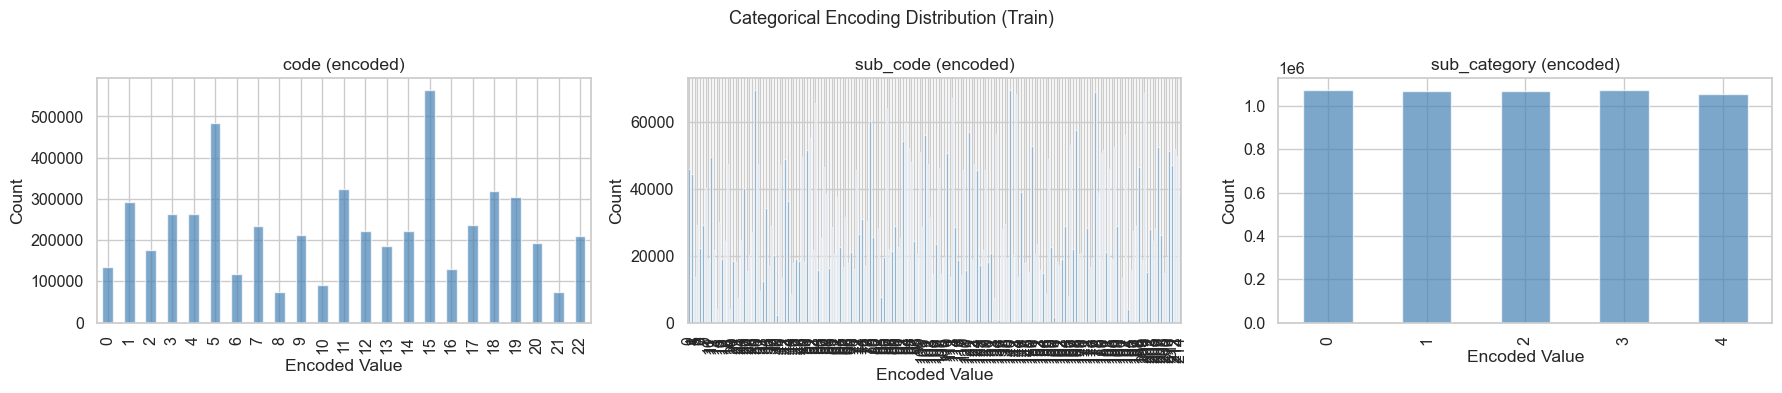

In [21]:
# Visual: distribution of encoded categories
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, CAT_COLS):
    enc_col = f'{col}_encoded'
    train[enc_col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{col} (encoded)')
    ax.set_xlabel('Encoded Value')
    ax.set_ylabel('Count')
plt.suptitle('Categorical Encoding Distribution (Train)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Step 5 — Target Clipping

**EDA evidence:** Target has kurtosis ≈ 290 with values ranging from −2202 to
+2314. The 1st and 99th percentiles are much narrower. Clipping removes extreme
outliers that would dominate loss.

In [23]:
# Compute clip bounds from training data
target_p01 = train[TARGET_COL].quantile(0.01)
target_p99 = train[TARGET_COL].quantile(0.99)
print(f'Clip bounds: [{target_p01:.4f}, {target_p99:.4f}]')
print(f'Before clipping — min: {train[TARGET_COL].min():.4f}, max: {train[TARGET_COL].max():.4f}')
print(f'Before clipping — kurtosis: {train[TARGET_COL].kurtosis():.2f}')

Clip bounds: [-82.7972, 62.9234]
Before clipping — min: -2201.8816, max: 2314.4112
Before clipping — kurtosis: 289.77


In [24]:
train['y_target_clipped'] = train[TARGET_COL].clip(target_p01, target_p99)

print(f'After clipping  — min: {train["y_target_clipped"].min():.4f}, max: {train["y_target_clipped"].max():.4f}')
print(f'After clipping  — kurtosis: {train["y_target_clipped"].kurtosis():.2f}')

After clipping  — min: -82.7972, max: 62.9234
After clipping  — kurtosis: 23.48


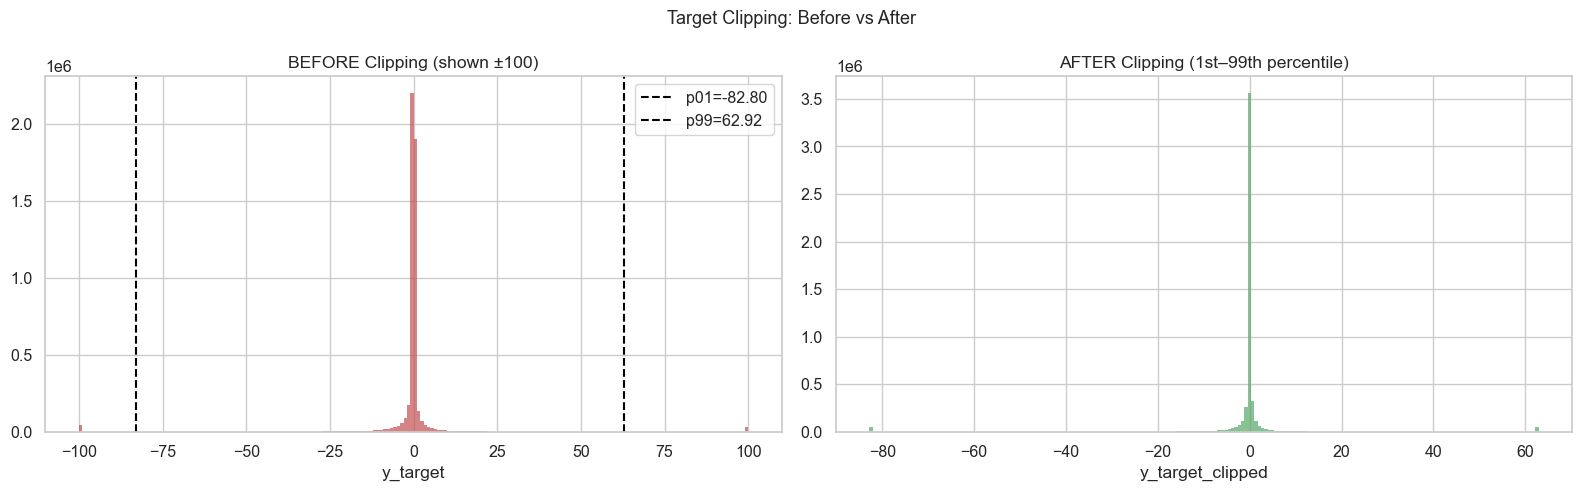

In [25]:
# Visual: Before vs After clipping
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(train[TARGET_COL].clip(-100, 100), bins=200, color='#C44E52', alpha=0.7, edgecolor='none')
axes[0].axvline(target_p01, color='black', linestyle='--', label=f'p01={target_p01:.2f}')
axes[0].axvline(target_p99, color='black', linestyle='--', label=f'p99={target_p99:.2f}')
axes[0].set_title('BEFORE Clipping (shown ±100)')
axes[0].set_xlabel('y_target')
axes[0].legend()

axes[1].hist(train['y_target_clipped'], bins=200, color='#55A868', alpha=0.7, edgecolor='none')
axes[1].set_title('AFTER Clipping (1st–99th percentile)')
axes[1].set_xlabel('y_target_clipped')

plt.suptitle('Target Clipping: Before vs After', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Step 6 — Horizon-Normalised Target

**EDA evidence:** Target std scales from 11.7 (h=1) to 52.8 (h=25). Without
normalisation, long-horizon samples dominate the loss. We divide by horizon-
specific std to create a "standardised" target.

In [27]:
# Compute horizon-specific stats from TRAIN clipped target
horizon_stats = train.groupby('horizon')['y_target_clipped'].agg(['mean', 'std']).rename(
    columns={'mean': 'h_mean', 'std': 'h_std'}
)
print('=== Horizon Stats (from clipped target) ===')
display(horizon_stats)

=== Horizon Stats (from clipped target) ===


,h_mean,h_std
horizon,,
1,-0.1815,8.2039
3,-0.4199,11.4224
10,-0.8373,14.7328
25,-1.2855,17.0365


In [28]:
# Create normalised target: (y - horizon_mean) / horizon_std
train = train.merge(horizon_stats, left_on='horizon', right_index=True, how='left')
train['y_target_hnorm'] = (train['y_target_clipped'] - train['h_mean']) / train['h_std']
train.drop(columns=['h_mean', 'h_std'], inplace=True)

print('=== Horizon-Normalised Target Stats ===')
for h in sorted(train['horizon'].unique()):
    sub = train[train['horizon'] == h]['y_target_hnorm']
    print(f'  h={h:2d}: mean={sub.mean():.6f}, std={sub.std():.4f}')

=== Horizon-Normalised Target Stats ===
  h= 1: mean=0.000000, std=1.0000
  h= 3: mean=-0.000000, std=1.0000
  h=10: mean=0.000000, std=1.0000
  h=25: mean=-0.000000, std=1.0000


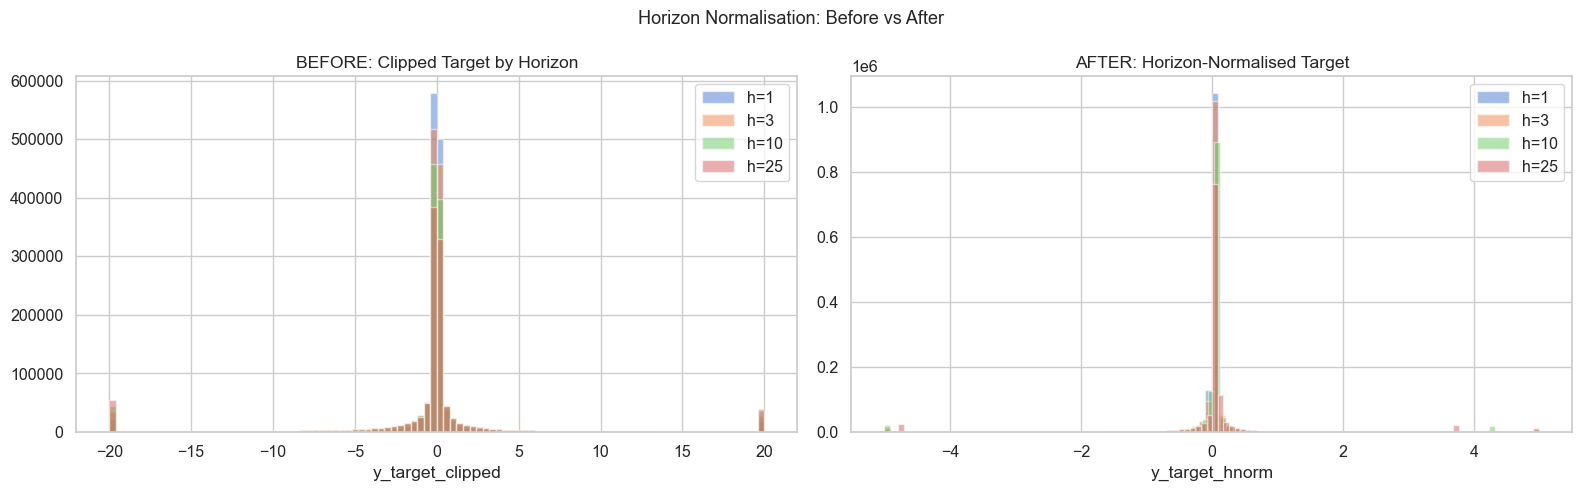

In [29]:
# Visual: Before vs After horizon normalisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for h in sorted(train['horizon'].unique()):
    sub = train[train['horizon'] == h]
    axes[0].hist(sub['y_target_clipped'].clip(-20, 20), bins=100, alpha=0.5, label=f'h={h}')
    axes[1].hist(sub['y_target_hnorm'].clip(-5, 5), bins=100, alpha=0.5, label=f'h={h}')

axes[0].set_title('BEFORE: Clipped Target by Horizon')
axes[0].set_xlabel('y_target_clipped')
axes[0].legend()

axes[1].set_title('AFTER: Horizon-Normalised Target')
axes[1].set_xlabel('y_target_hnorm')
axes[1].legend()

plt.suptitle('Horizon Normalisation: Before vs After', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Step 7 — Weight Handling (Scoring Only)

**Important:** The `weight` column is **not used during training**. It is only
used to compute the evaluation metric (weighted RMSE) after predictions are
made. Therefore, we do **not** transform weights — we simply keep them as-is
and drop zero-weight rows (which contribute nothing to the score).

In [31]:
# Weight summary (kept as-is — only used for scoring)
n_zero_weight = (train[WEIGHT_COL] == 0).sum()
print(f'Zero-weight rows: {n_zero_weight:,} ({n_zero_weight/len(train)*100:.2f}%)')
print(f'Weight range: [{train[WEIGHT_COL].min():.2f}, {train[WEIGHT_COL].max():.2e}]')
print(f'\nWeights are NOT transformed — they are only used for weighted RMSE scoring.')

Zero-weight rows: 4,981 (0.09%)
Weight range: [0.00, 1.39e+13]

Weights are NOT transformed — they are only used for weighted RMSE scoring.


In [32]:
# Drop zero-weight rows (they contribute nothing to scoring)
train = train[train[WEIGHT_COL] > 0].reset_index(drop=True)
print(f'Rows after dropping zero-weight: {len(train):,}')
print(f'Weight column kept as-is (raw values preserved for weighted RMSE).')

Rows after dropping zero-weight: 5,332,433
Weight column kept as-is (raw values preserved for weighted RMSE).


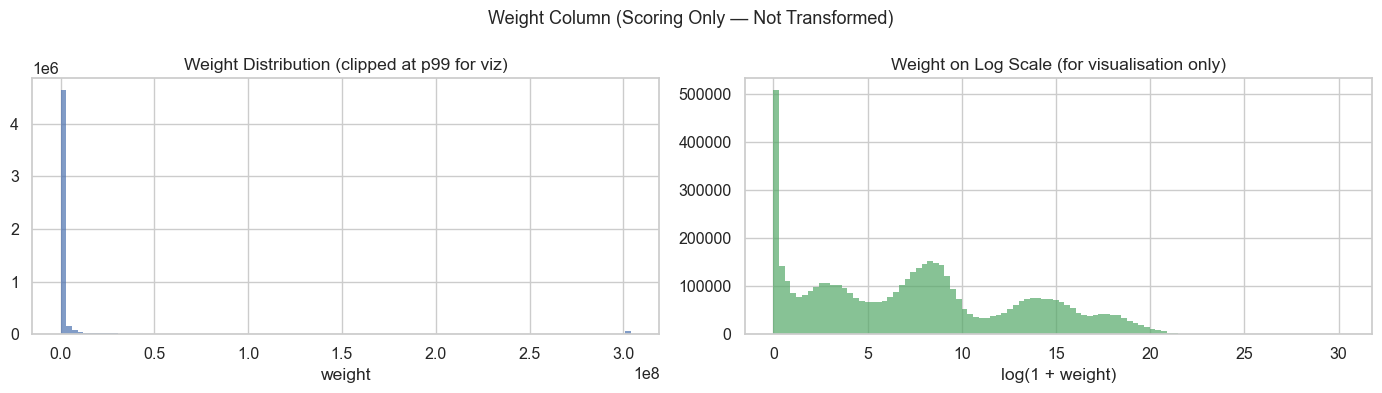

In [33]:
# Visual: Weight distribution (kept as-is, zero-weight rows dropped)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train[WEIGHT_COL].clip(0, train[WEIGHT_COL].quantile(0.99)),
             bins=100, color='#4C72B0', alpha=0.7, edgecolor='none')
axes[0].set_title('Weight Distribution (clipped at p99 for viz)')
axes[0].set_xlabel('weight')

axes[1].hist(np.log1p(train[WEIGHT_COL]), bins=100, color='#55A868', alpha=0.7, edgecolor='none')
axes[1].set_title('Weight on Log Scale (for visualisation only)')
axes[1].set_xlabel('log(1 + weight)')

plt.suptitle('Weight Column (Scoring Only — Not Transformed)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Preprocessing Summary & Validation

In [35]:
# Final sanity checks
feature_cols_final = [c for c in train.columns if c.startswith('feature_')]
flag_cols = [c for c in train.columns if c.endswith('_is_missing')]

print('=' * 60)
print('PREPROCESSING SUMMARY')
print('=' * 60)
print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')
print(f'Feature columns: {len(feature_cols_final)}')
print(f'Missing flags:   {len(flag_cols)}')
print(f'Encoded cats:    {encoded_cat_cols}')
print(f'\nTrain missing values (features): {train[feature_cols_final].isnull().sum().sum()}')
print(f'Test  missing values (features): {test[[c for c in feature_cols_final if c in test.columns]].isnull().sum().sum()}')
print(f'\nTarget columns:')
print(f'  y_target          — raw (original)')
print(f'  y_target_clipped  — clipped at p01/p99')
print(f'  y_target_hnorm    — horizon-normalised')
print(f'\nWeight column:')
print(f'  weight            — raw (kept as-is, used only for weighted RMSE scoring)')
print(f'  (zero-weight rows dropped)')
print(f'\nHorizon stats used for normalisation:')
display(horizon_stats)

PREPROCESSING SUMMARY
Train shape: (5332433, 95)
Test  shape: (1447107, 91)
Feature columns: 82
Missing flags:   5
Encoded cats:    ['code_encoded', 'sub_code_encoded', 'sub_category_encoded']

Train missing values (features): 0
Test  missing values (features): 25578

Target columns:
  y_target          — raw (original)
  y_target_clipped  — clipped at p01/p99
  y_target_hnorm    — horizon-normalised

Weight column:
  weight            — raw (kept as-is, used only for weighted RMSE scoring)
  (zero-weight rows dropped)

Horizon stats used for normalisation:


,h_mean,h_std
horizon,,
1,-0.1815,8.2039
3,-0.4199,11.4224
10,-0.8373,14.7328
25,-1.2855,17.0365


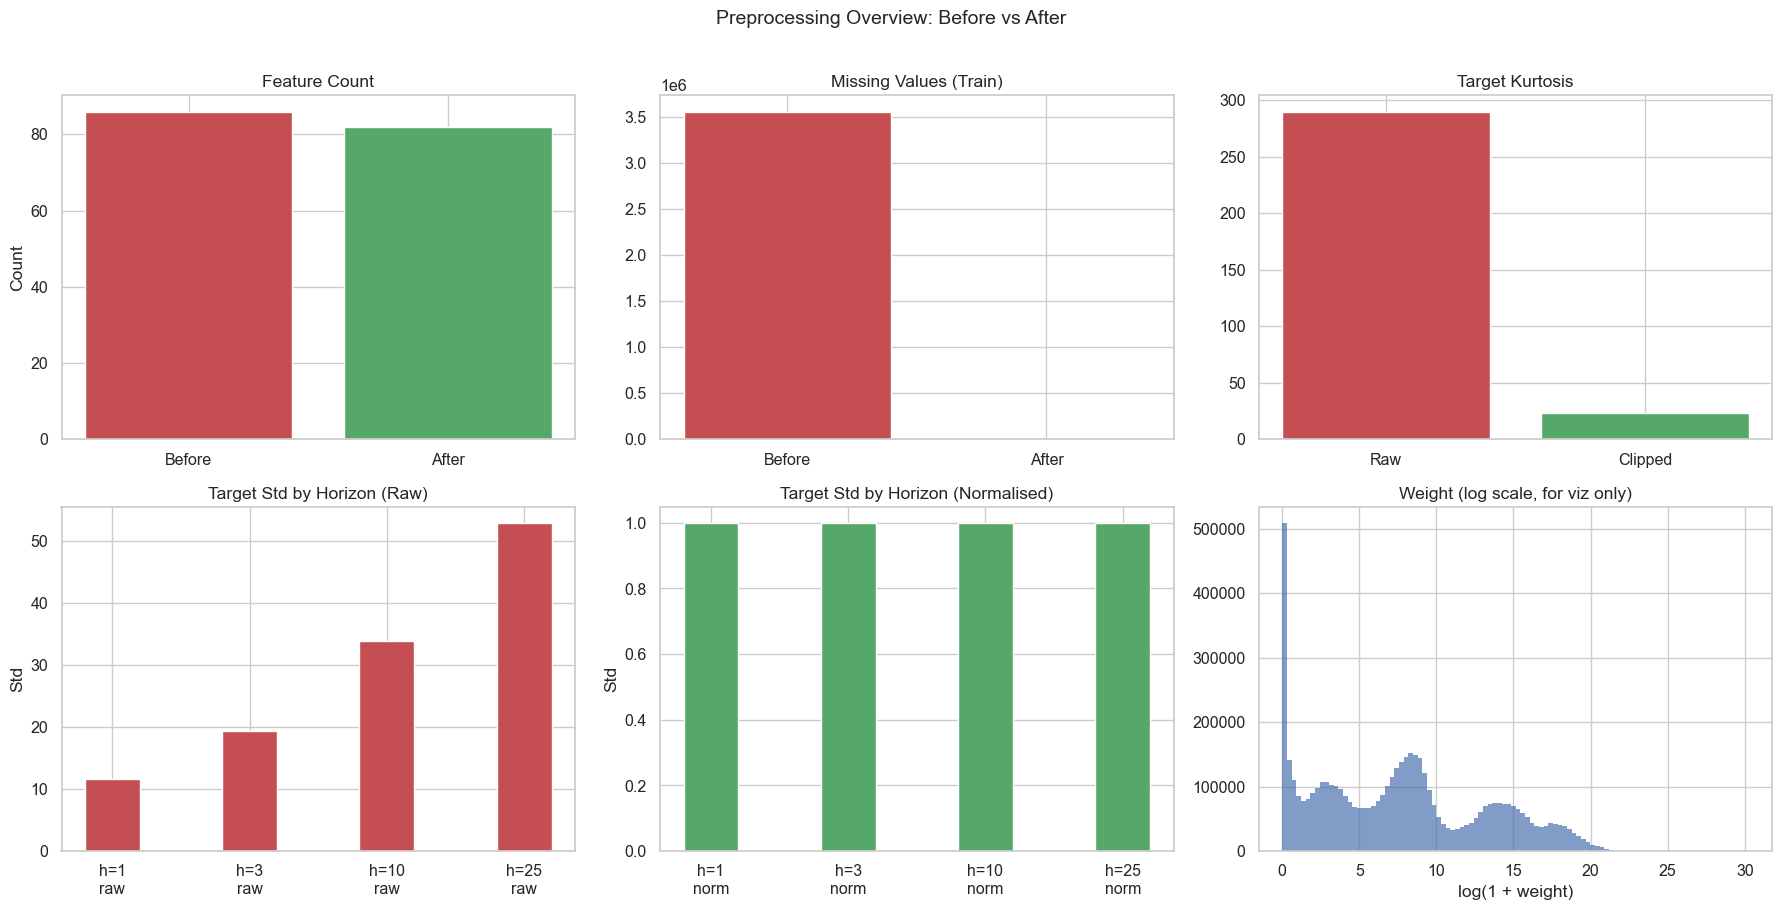

In [36]:
# Visual: comprehensive before/after overview
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1. Feature count
axes[0, 0].bar(['Before', 'After'], [len(ALL_FEATURE_COLS), len(feature_cols_final)],
               color=['#C44E52', '#55A868'])
axes[0, 0].set_title('Feature Count')
axes[0, 0].set_ylabel('Count')

# 2. Missing values
axes[0, 1].bar(['Before', 'After'], [missing_before_train, 0],
               color=['#C44E52', '#55A868'])
axes[0, 1].set_title('Missing Values (Train)')

# 3. Target kurtosis
axes[0, 2].bar(['Raw', 'Clipped'], [train_raw[TARGET_COL].kurtosis(), train['y_target_clipped'].kurtosis()],
               color=['#C44E52', '#55A868'])
axes[0, 2].set_title('Target Kurtosis')

# 4. Target std by horizon (before)
for h in sorted(train['horizon'].unique()):
    std_raw = train_raw[train_raw['horizon'] == h][TARGET_COL].std()
    std_norm = train[train['horizon'] == h]['y_target_hnorm'].std()
    axes[1, 0].bar(f'h={h}\nraw', std_raw, color='#C44E52', width=0.4)

axes[1, 0].set_title('Target Std by Horizon (Raw)')
axes[1, 0].set_ylabel('Std')

# 5. Target std by horizon (after)
for h in sorted(train['horizon'].unique()):
    std_norm = train[train['horizon'] == h]['y_target_hnorm'].std()
    axes[1, 1].bar(f'h={h}\nnorm', std_norm, color='#55A868', width=0.4)

axes[1, 1].set_title('Target Std by Horizon (Normalised)')
axes[1, 1].set_ylabel('Std')

# 6. Weight distribution (raw — kept as-is for scoring)
axes[1, 2].hist(np.log1p(train[WEIGHT_COL]), bins=100, color='#4C72B0', alpha=0.7, edgecolor='none')
axes[1, 2].set_title('Weight (log scale, for viz only)')
axes[1, 2].set_xlabel('log(1 + weight)')

plt.suptitle('Preprocessing Overview: Before vs After', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Save Processed Data & Reusable Pipeline

In [38]:
# Save processed parquets
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

train.to_parquet(os.path.join(PROCESSED_DIR, 'train_processed.parquet'), index=False)
test.to_parquet(os.path.join(PROCESSED_DIR, 'test_processed.parquet'), index=False)

print(f'Saved processed train: {os.path.join(PROCESSED_DIR, "train_processed.parquet")}')
print(f'Saved processed test:  {os.path.join(PROCESSED_DIR, "test_processed.parquet")}')
print(f'Train: {train.shape}  |  Test: {test.shape}')

Saved processed train: ../data/processed/train_processed.parquet
Saved processed test:  ../data/processed/test_processed.parquet
Train: (5332433, 95)  |  Test: (1447107, 91)


In [65]:
# Save horizon stats for inference-time normalisation
import json

preprocess_config = {
    'noise_features': NOISE_FEATURES,
    'redundant_features': REDUNDANT_FEATURES,
    'features_to_drop': FEATURES_TO_DROP,
    'high_missing_features': HIGH_MISSING_FEATURES,
    'target_clip_lower': float(target_p01),
    'target_clip_upper': float(target_p99),
    'horizon_stats': horizon_stats.to_dict(),
    'global_medians': {k: float(v) for k, v in global_medians.items()},
    'cat_cols': CAT_COLS,
    'encoded_cat_cols': encoded_cat_cols,
}

config_path = os.path.join(PIPELINE_DIR, 'preprocess_config.json')
with open(config_path, 'w') as f:
    json.dump(preprocess_config, f, indent=2, default=str)

print(f'Saved preprocessing config: {config_path}')

Saved preprocessing config: ../pipeline/preprocess_config.json


In [67]:
# Save group medians for imputation at inference time
group_medians.to_parquet(os.path.join(PIPELINE_DIR, 'group_medians.parquet'))
print(f'Saved group medians: {os.path.join(PIPELINE_DIR, "group_medians.parquet")}')

Saved group medians: ../pipeline/group_medians.parquet


---
## 11. Final Column Inventory

For downstream notebooks (feature engineering, modelling), here is the complete
list of columns in the processed data.

In [76]:
print('=== Processed Train Columns ===')
col_groups = {
    'Meta':           [c for c in train.columns if c in META_COLS],
    'Encoded Cats':   [c for c in train.columns if c.endswith('_encoded')],
    'Features':       [c for c in train.columns if c.startswith('feature_')],
    'Missing Flags':  [c for c in train.columns if c.endswith('_is_missing')],
    'Targets':        [c for c in train.columns if 'y_target' in c],
    'Weights':        [c for c in train.columns if 'weight' in c],
}

for group, cols in col_groups.items():
    print(f'\n  {group} ({len(cols)}):')
    for c in cols:
        dtype = train[c].dtype
        print(f'    {c:30s} {str(dtype):10s}')

print(f'\n  Total columns: {train.shape[1]}')

=== Processed Train Columns ===

  Meta (6):
    id                             object    
    code                           object    
    sub_code                       object    
    sub_category                   object    
    horizon                        int32     
    ts_index                       int32     

  Encoded Cats (3):
    code_encoded                   int64     
    sub_code_encoded               int64     
    sub_category_encoded           int64     

  Features (82):
    feature_a                      int32     
    feature_h                      float64   
    feature_i                      float64   
    feature_j                      float64   
    feature_k                      float64   
    feature_l                      float64   
    feature_m                      float64   
    feature_n                      float64   
    feature_o                      float64   
    feature_p                      float64   
    feature_q                      float64

In [78]:
print('Preprocessing complete.')
print(f'\nFiles saved:')
print(f'  data/processed/train_processed.parquet  ({train.shape[0]:,} × {train.shape[1]})')
print(f'  data/processed/test_processed.parquet   ({test.shape[0]:,} × {test.shape[1]})')
print(f'  pipeline/preprocess_config.json')
print(f'  pipeline/group_medians.parquet')
print(f'  pipeline/preprocess.py')

Preprocessing complete.

Files saved:
  data/processed/train_processed.parquet  (5,332,433 × 95)
  data/processed/test_processed.parquet   (1,447,107 × 91)
  pipeline/preprocess_config.json
  pipeline/group_medians.parquet
  pipeline/preprocess.py
